In [1]:
!pip install pysm3 healpy astropy matplotlib numpy scipy

  Using cached h5py-3.16.0-cp313-cp313-manylinux_2_28_x86_64.whl.metadata (3.0 kB)
  Using cached astropy_iers_data-0.2026.6.15.15.33.16-py3-none-any.whl.metadata (3.4 kB)
  Using cached pyerfa-2.0.1.5-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 9.0 MB/s  0:00:006m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 19.8 MB/s  0:00:00m0:00:010:01
Using cached astropy_iers_data-0.2026.6.15.15.33.16-py3-none-any.whl (2.0 MB)
Using cached pyerfa-2.0.1.5-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (738 kB)
Using cached h5py-3.16.0-cp313-cp313-manylinux_2_28_x86_64.whl (5.4 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 19.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 30.2 MB/s  0:00:01m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [pysm3]32m8/9 [pysm3]]]]

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice]

/tmp/ipykernel_13807/1065527692.py:84: HealpyDeprecationWarning: "verbose" was deprecated in version 1.15.0 and will be removed in a future version. 
  noise_1f = hp.alm2map(alm, NSIDE, verbose=False)
/media/lbarosi/barosi_portable/CODE/dissertacao_Vanderson_2026/.venv/lib/python3.13/site-packages/healpy/visufunc.py:223: UserWarning: Ignoring specified arguments in this call because figure with num: 2 already exists
  f = pylab.figure(fig, figsize=(8.5, 5.4))


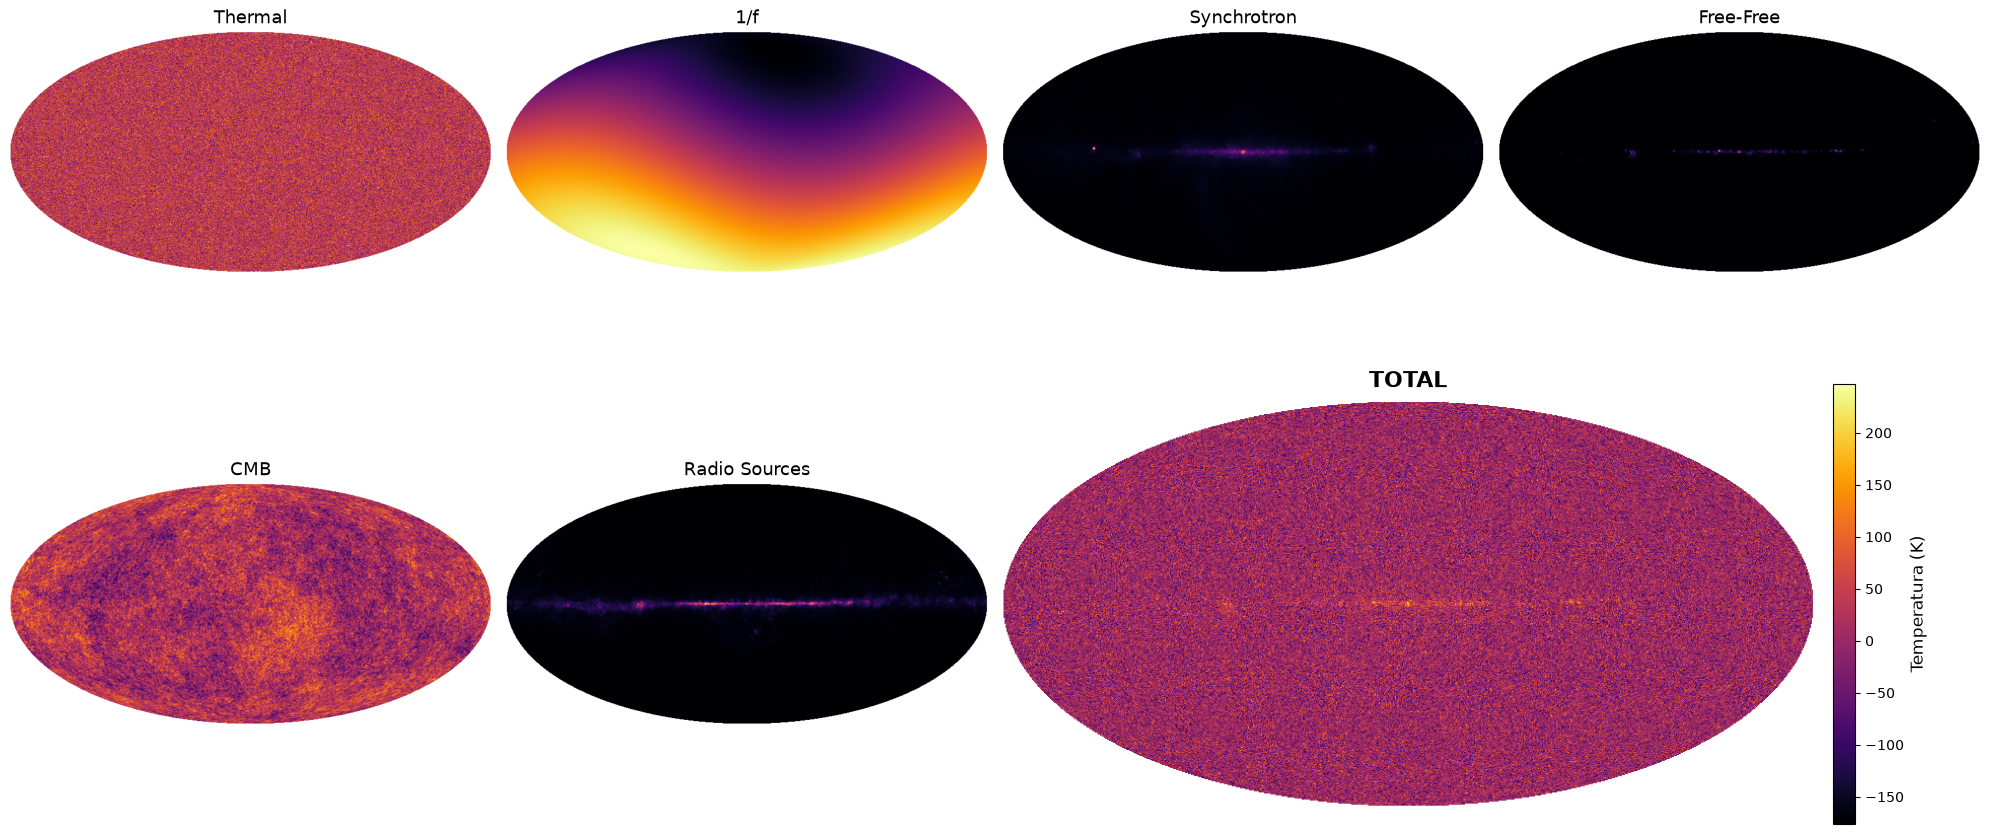

In [ ]:
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import pysm3
import pysm3.units as u

# ======================================================
# Configuração
# ======================================================

NSIDE = 128
FREQ = 1100 * u.MHz

NPIX = hp.nside2npix(NSIDE)

np.random.seed(42)

# ======================================================
# PySM3
# ======================================================

sky = pysm3.Sky(
    nside=NSIDE,
    preset_strings=[
        "s1",  # synchrotron
        "f1",  # free-free
        "c1",  # CMB
        "d1",  # radio sources
    ],
)

# ======================================================
# Componentes astrofísicas
# ======================================================

synch = sky.components[0].get_emission(FREQ)[0]

freefree = sky.components[1].get_emission(FREQ)[0]

cmb = sky.components[2].get_emission(FREQ)[0]

radiosources = sky.components[3].get_emission(FREQ)[0]

# ======================================================
# Converter para Kelvin
# ======================================================

synch = synch.to(u.K_RJ).value

freefree = freefree.to(u.K_RJ).value

cmb = cmb.to(u.K_RJ).value

radiosources = radiosources.to(u.K_RJ).value

# ======================================================
# Ruído térmico
# ======================================================

Tsys = 40.0

thermal = np.random.normal(loc=0, scale=Tsys, size=NPIX)

# ======================================================
# Ruído 1/f
# ======================================================

white = np.random.normal(size=NPIX)

alm = hp.map2alm(white)

lmax = hp.Alm.getlmax(len(alm))

ells = np.arange(lmax + 1)

beta = 1.0

filter_1f = np.ones_like(ells)

filter_1f[1:] = ells[1:] ** (-beta / 2)

alm *= filter_1f[hp.Alm.getlm(lmax)[0]]

noise_1f = hp.alm2map(alm, NSIDE, verbose=False)

noise_1f *= 5

# ======================================================
# Soma
# ======================================================

total = thermal + noise_1f + synch + freefree + radiosources + cmb

# ======================================================
# Plotagem — modo OO com GridSpec
# ======================================================
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(20, 10))
gs = GridSpec(2, 4, figure=fig)

# Layout: 2 linhas × 4 colunas
# TOTAL ocupa 2 colunas na 2ª linha (destaque)
layout = [
    ("Thermal", thermal, gs[0, 0]),
    ("1/f", noise_1f, gs[0, 1]),
    ("Synchrotron", synch, gs[0, 2]),
    ("Free-Free", freefree, gs[0, 3]),
    ("CMB", cmb, gs[1, 0]),
    ("Radio Sources", radiosources, gs[1, 1]),
    ("TOTAL", total, gs[1, 2:]),  # ← spanning 2 colunas
]

for titulo, mapa, pos in layout:
    ax = fig.add_subplot(pos)

    # Projeta o mapa com healpy em figura oculta e extrai a imagem
    img = hp.mollview(mapa, return_projected_map=True)
    plt.close()  # fecha a figura temporária criada pelo mollview

    im = ax.imshow(img, cmap="inferno", aspect="equal")
    ax.axis("off")

    # Título com destaque para o TOTAL
    if titulo == "TOTAL":
        ax.set_title(titulo, fontsize=16, fontweight="bold", pad=10)
    else:
        ax.set_title(titulo, fontsize=13)

# Barra de cores ao lado do TOTAL (destacado)
cbar = fig.colorbar(im, ax=fig.get_axes()[-1], shrink=0.85, pad=0.02)
cbar.set_label("Temperatura (K)", fontsize=12)

plt.tight_layout()
plt.show()